In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # use GPU 1

from dingo.core.posterior_models.build_model import build_model_from_kwargs

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/imbh_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.


In [2]:
import numpy as np
import itertools
import os
import pickle

# ============================================================
# Parameter grid
# ============================================================

chirp_masses = np.arange(100, 701, 10)

mass_ratios = np.arange(0.2, 1.01, 0.05)


parameter_grid = list(
    itertools.product(
        chirp_masses,
        mass_ratios
    )
)
print(mass_ratios)
print(f"Total injections: {len(parameter_grid)}")

[0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85
 0.9  0.95 1.  ]
Total injections: 1037


In [3]:
import os
import pickle
import numpy as np

import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset


# ============================================================
# Setup
# ============================================================

os.makedirs("/scratch/tpausch/test_data/imbh_T2/injections", exist_ok=True)

injection_generator = injection.Injection.from_posterior_model_metadata(
    main_pm.metadata
)

asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]

asd_dataset = ASDDataset(file_name=asd_fname)

injection_generator.asd = {
    k: v[0] for k, v in asd_dataset.asds.items()
}



for idx, (cm, q) in enumerate(parameter_grid):

    print(f"Running injection {idx}")

    intrinsic_parameters = {
        "chirp_mass": float(cm),
        "mass_ratio": float(q),
        "a_1": 0.3,
        "a_2": 0.5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {
        **intrinsic_parameters,
        **extrinsic_parameters
    }

    strain_data = injection_generator.injection(theta)

    payload = {
        "theta_true": theta,
        "strain_data": strain_data,
    }

    fname = f"/scratch/tpausch/test_data/imbh_T2/injections/inj_{idx:04d}.pkl"

    with open(fname, "wb") as f:
        pickle.dump(payload, f)

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running injection 0
Running injection 1
Running injection 2
Running injection 3
Running injection 4
Running injection 5
Running injection 6
Running injection 7
Running injection 8
Running injection 9
Running injection 10
Running injection 11
Running injection 12
Running injection 13
Running injection 14
Running injection 15
Running injection 16
Running injection 17
Running injection 18
Running injection 19
Running injection 20
Running injection 21
Running injection 22
Running injection 23
Running injection 24
Running injection 25
Running injection 26
Running injection 27
Running injection 28
Running injection 29
Running injection 30
Running injection 31
Running injection 32
Running injection 33
Running injection 34
Running injection 35
Running injection 36
Running injection 37
Running injection 38
Running injection 39
Runni

In [4]:
import os
import pickle

from dingo.gw.inference.gw_samplers import GWSampler


os.makedirs("/scratch/tpausch/test_data/imbh_T2/results", exist_ok=True)

injection_files = sorted(os.listdir("/scratch/tpausch/test_data/imbh_T2/injections"))

for fname in injection_files:

    # --------------------------------------------------------
    # Load injection
    # --------------------------------------------------------

    with open(f"/scratch/tpausch/test_data/imbh_T2/injections/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    strain_data = payload["strain_data"]

    # --------------------------------------------------------
    # Run sampler
    # --------------------------------------------------------

    sampler = GWSampler(model=main_pm)

    sampler.context = strain_data

    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    result_payload = {
        "theta_true": theta_true,
        "result": result,
    }

    outname = fname.replace("inj_", "result_")

    with open(f"/scratch/tpausch/test_data/imbh_T2/results/{outname}", "wb") as f:
        pickle.dump(result_payload, f)

    print(f"Saved /scratch/tpausch/test_data/imbh_T2/results/{outname}")

Running sampler to generate 50000 samples.
Done. This took 5.1 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T2/results/result_0000.pkl
Running sampler to generate 50000 samples.
Done. This took 4.8 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T2/results/result_0001.pkl
Running sampler to generate 50000 samples.
Done. This took 4.8 s.


...

Saved /scratch/tpausch/test_data/imbh_T2/results/result_1034.pkl
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T2/results/result_1035.pkl
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Saved /scratch/tpausch/test_data/imbh_T2/results/result_1036.pkl


In [5]:
import os
import pickle
import numpy as np

true_cm = []
true_mr = []
mass_ratio_error = []
mass_ratio_std = []
chirp_mass_error = []
chirp_mass_std = []


result_files = sorted(os.listdir("/scratch/tpausch/test_data/imbh_T2/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/imbh_T2/results/{fname}", "rb") as f:
        payload = pickle.load(f)

    theta_true = payload["theta_true"]
    result = payload["result"]

    posterior_samples = result.samples

    q_samples = np.array(posterior_samples["mass_ratio"])

    # inference statistics
    q_mean = np.mean(q_samples)
    q_std = np.std(q_samples)

    true_q = theta_true["mass_ratio"]

    cm_samples = np.array(posterior_samples["chirp_mass"])

    cm_mean = np.mean(cm_samples)
    cm_std = np.std(cm_samples)

    true_mr.append(theta_true["mass_ratio"])
    true_cm.append(theta_true["chirp_mass"])
    mass_ratio_error.append(q_mean - true_q)
    mass_ratio_std.append(q_std)
    chirp_mass_error.append(cm_mean - theta_true["chirp_mass"])
    chirp_mass_std.append(cm_std)

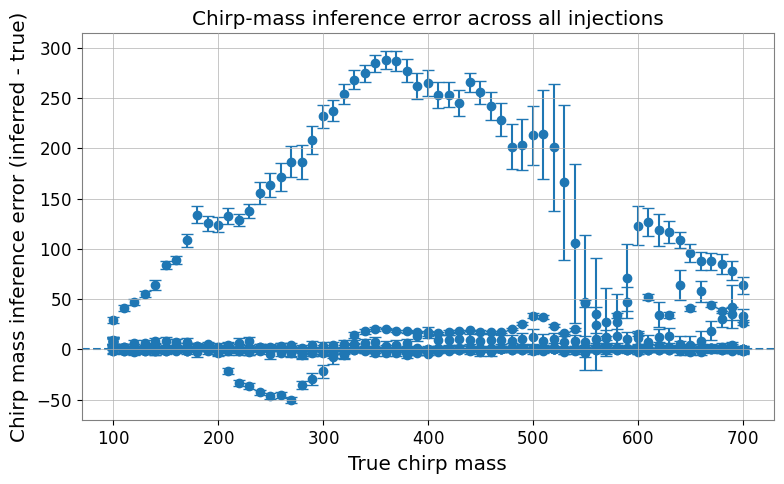

In [6]:
import matplotlib.pyplot as plt
import numpy as np


true_mr = np.array(true_mr)
true_cm = np.array(true_cm)
chirp_mass_error = np.array(chirp_mass_error)
chirp_mass_std = np.array(chirp_mass_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_cm,
    chirp_mass_error,
    yerr=chirp_mass_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True chirp mass")
plt.ylabel("Chirp mass inference error (inferred - true)")
plt.title("Chirp-mass inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

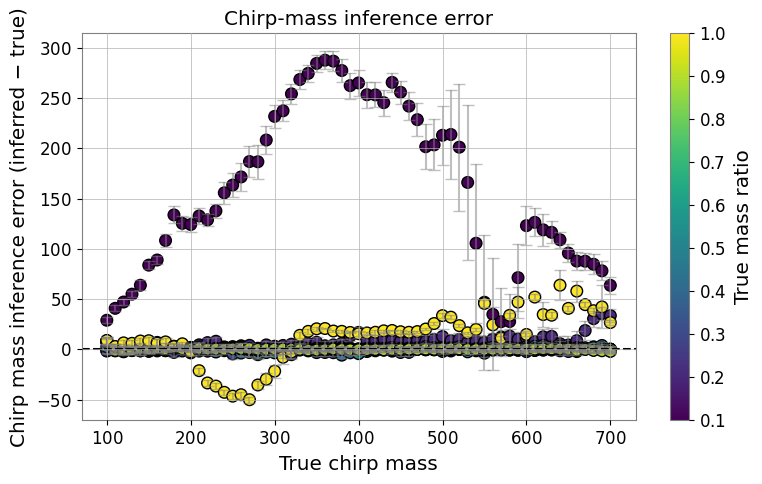

In [7]:
import matplotlib.pyplot as plt
import numpy as np

true_mr = np.array(true_mr)
true_cm = np.array(true_cm)

chirp_mass_error = np.array(chirp_mass_error)
chirp_mass_std = np.array(chirp_mass_std)

plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Error bars
# ------------------------------------------------------------

plt.errorbar(
    true_cm,
    chirp_mass_error,
    yerr=chirp_mass_std,
    fmt="none",
    capsize=4,
    alpha=0.5,
    color="gray",
)

# ------------------------------------------------------------
# Colored scatter points
# ------------------------------------------------------------

sc = plt.scatter(
    true_cm,
    chirp_mass_error,
    c=true_mr,
    cmap="viridis",
    s=70,
    edgecolor="black",
)

# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axhline(0, linestyle="--", color="black")

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(sc)
cbar.set_label("True mass ratio")

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("True chirp mass")
plt.ylabel("Chirp mass inference error (inferred − true)")

plt.title("Chirp-mass inference error")

plt.grid(True)

plt.tight_layout()
plt.show()

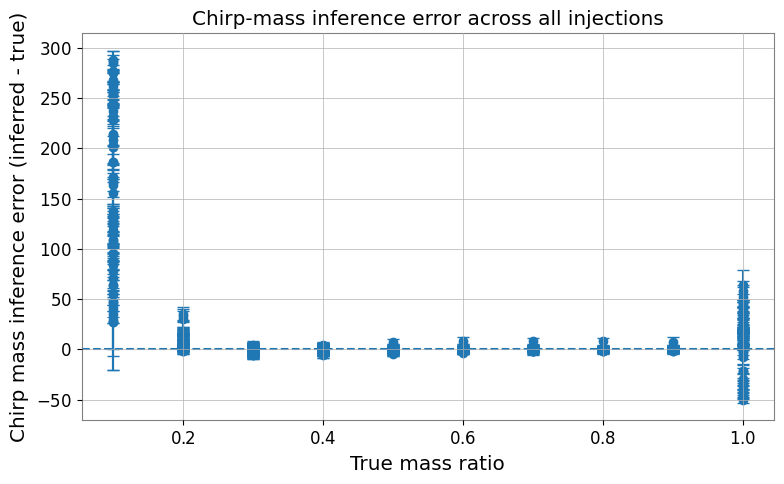

In [8]:
import matplotlib.pyplot as plt
import numpy as np

true_mr = np.array(true_mr)
chirp_mass_error = np.array(chirp_mass_error)
chirp_mass_std = np.array(chirp_mass_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_mr,
    chirp_mass_error,
    yerr=chirp_mass_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True mass ratio")
plt.ylabel("Chirp mass inference error (inferred - true)")
plt.title("Chirp-mass inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

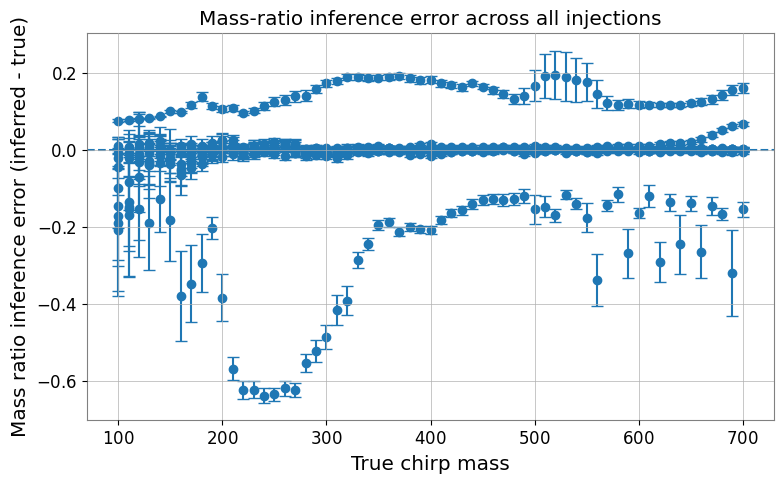

In [9]:
import matplotlib.pyplot as plt
import numpy as np

true_cm = np.array(true_cm)
mass_ratio_error = np.array(mass_ratio_error)
mass_ratio_std = np.array(mass_ratio_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_cm,
    mass_ratio_error,
    yerr=mass_ratio_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True chirp mass")
plt.ylabel("Mass ratio inference error (inferred - true)")
plt.title("Mass-ratio inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

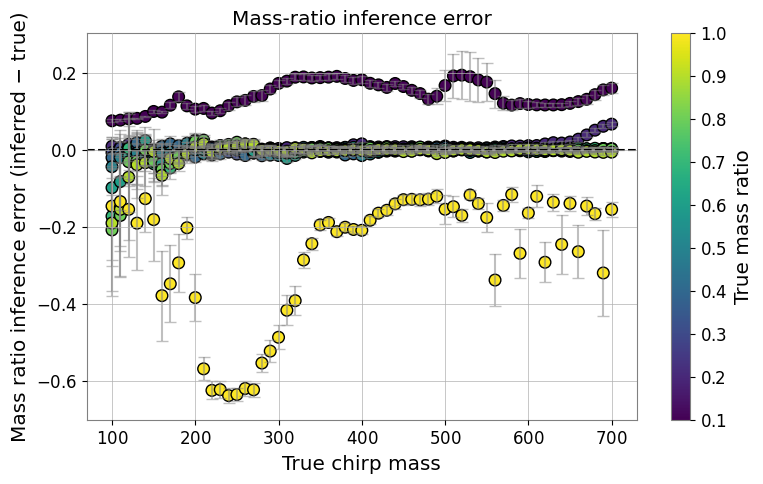

In [10]:
import matplotlib.pyplot as plt
import numpy as np

true_mr = np.array(true_mr)
true_cm = np.array(true_cm)



mass_ratio_error = np.array(mass_ratio_error)
mass_ratio_std = np.array(mass_ratio_std)


plt.figure(figsize=(8, 5))

# ------------------------------------------------------------
# Error bars
# ------------------------------------------------------------

plt.errorbar(
    true_cm,
    mass_ratio_error,
    yerr=mass_ratio_std,
    fmt="none",
    capsize=4,
    alpha=0.5,
    color="gray",
)

# ------------------------------------------------------------
# Colored scatter points
# ------------------------------------------------------------

sc = plt.scatter(
    true_cm,
    mass_ratio_error,
    c=true_mr,
    cmap="viridis",
    s=70,
    edgecolor="black",
)

# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axhline(0, linestyle="--", color="black")

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = plt.colorbar(sc)
cbar.set_label("True mass ratio")

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("True chirp mass")
plt.ylabel("Mass ratio inference error (inferred − true)")

plt.title("Mass-ratio inference error")

plt.grid(True)

plt.tight_layout()
plt.show()

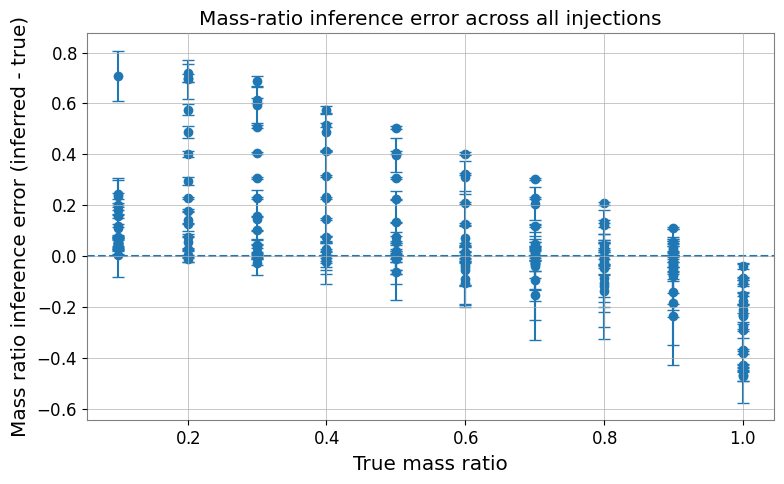

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

true_mr = np.array(true_mr)
mass_ratio_error = np.array(mass_ratio_error)
mass_ratio_std = np.array(mass_ratio_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    true_mr,
    mass_ratio_error,
    yerr=mass_ratio_std,
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")

plt.xlabel("True mass ratio")
plt.ylabel("Mass ratio inference error (inferred - true)")
plt.title("Mass-ratio inference error across all injections")

plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
pp_values_chirp_mass = []
pp_values_mass_ratio = []

result_files = sorted(os.listdir("/scratch/tpausch/test_data/imbh_T2/results"))

for fname in result_files:

    with open(f"/scratch/tpausch/test_data/imbh_T2/results/{fname}", "rb") as f:

        payload = pickle.load(f)

        theta_true = payload["theta_true"]
        result = payload["result"]

        posterior_samples = result.samples


        # ============================================================
        # Chirp mass PP value
        # ============================================================

        cm_samples = posterior_samples["chirp_mass"]

        pp_cm = np.mean(
            cm_samples < theta_true["chirp_mass"]
        )

        pp_values_chirp_mass.append(pp_cm)


        # ============================================================
        # Mass ratio PP value
        # ============================================================

        q_samples = posterior_samples["mass_ratio"]

        pp_q = np.mean(
            q_samples < theta_true["mass_ratio"]
        )

        pp_values_mass_ratio.append(pp_q)




In [13]:
import matplotlib.pyplot as plt


def plot_pp(pp_values, label):

    pp_values = np.array(pp_values)

    sorted_pp = np.sort(pp_values)

    n = len(sorted_pp)

    empirical_cdf = np.arange(1, n + 1) / n

    x = np.linspace(0, 1, 200)

    sigma = np.sqrt(x * (1 - x) / n)

    plt.figure(figsize=(6, 6))

    # Ideal calibration
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Ideal calibration",
    )


    # Empirical PP curve
    plt.plot(
        sorted_pp,
        empirical_cdf,
        marker="o",
        label=label,
    )

    plt.xlabel("Credible level")
    plt.ylabel("Fraction of injections")

    plt.title(f"PP Plot: {label}")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

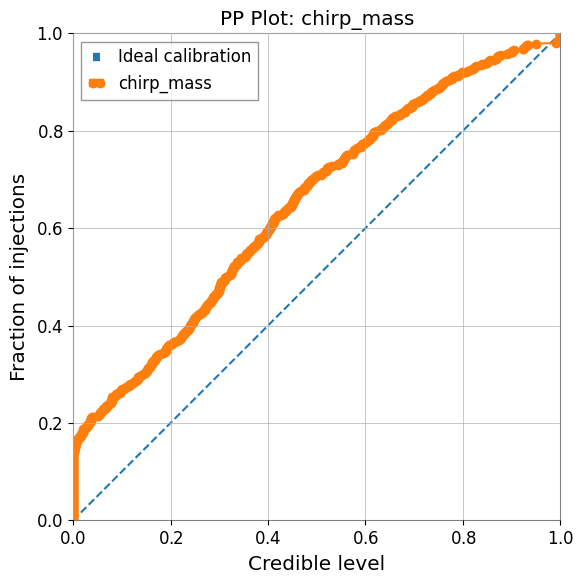

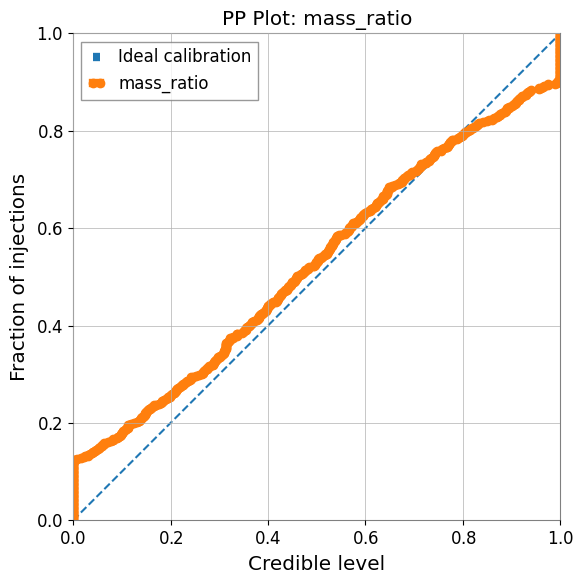

In [14]:


plot_pp(
    pp_values_chirp_mass,
    "chirp_mass",
)

plot_pp(
    pp_values_mass_ratio,
    "mass_ratio",
)